In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model

In [2]:
class ReverseDataset:
    def __init__(self, num_categories, seq_len, size):
        self.num_categories = num_categories
        self.seq_len = seq_len
        self.size = size

        self.data = np.random.randint(self.num_categories, size=(self.size, self.seq_len))

    def __len__(self):
        return self.size

    def __getitem__(self, idx):
        inp_data = self.data[idx]
        labels = np.flip(inp_data)
        return inp_data, labels

In [3]:
def make_dataset(dataset, batch_size, shuffle=True, drop_last=True):
    # Extract all samples
    x_all = np.stack([dataset[i][0] for i in range(len(dataset))])
    y_all = np.stack([dataset[i][1] for i in range(len(dataset))])

    tf_ds = tf.data.Dataset.from_tensor_slices((x_all, y_all))
    if shuffle:
        tf_ds = tf_ds.shuffle(buffer_size=len(dataset))
    tf_ds = tf_ds.batch(batch_size, drop_remainder=drop_last)
    return tf_ds

In [4]:
from functools import partial

NUM_CATEGORIES = 10
SEQ_LEN = 16

dataset = partial(ReverseDataset, num_categories=NUM_CATEGORIES, seq_len=SEQ_LEN)

train_dataset = dataset(size=50000)
val_dataset = dataset(size=1000)
test_dataset = dataset(size=10000)

train_loader = make_dataset(train_dataset, batch_size=128, shuffle=True, drop_last=True)
val_loader = make_dataset(val_dataset, batch_size=128)
test_loader = make_dataset(test_dataset, batch_size=128)

In [5]:
# Get first batch
for x_batch, y_batch in train_loader.take(1):
    # Get first sequence in the batch
    inp_data = x_batch[0].numpy()
    labels = y_batch[0].numpy()

print("Input data:", inp_data)
print("Labels:    ", labels)

Input data: [0 5 6 8 6 5 9 4 5 0 9 2 5 5 8 2]
Labels:     [2 8 5 5 2 9 0 5 4 9 5 6 8 6 5 0]


In [6]:
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        self.d_model = d_model

        # Create a matrix of shape [max_len, d_model]
        pos = np.arange(max_len)[:, np.newaxis]           # shape: [max_len, 1]
        i = np.arange(d_model)[np.newaxis, :]            # shape: [1, d_model]

        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        # Apply sin to even indices, cos to odd indices
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        # Register as a constant tensor
        self.pos_encoding = tf.constant(angle_rads, dtype=tf.float32)  # shape [max_len, d_model]

    def call(self, x):
        seq_len = tf.shape(x)[1]
        # x shape: [batch_size, seq_len, d_model]
        return x + self.pos_encoding[tf.newaxis, :seq_len, :]

In [7]:
class TransformerPredictor(Model):
    def __init__(self, input_dim, model_dim, num_classes, num_heads, num_layers,
                 dropout=0.0, input_dropout=0.0):
        super().__init__()
        self.input_dropout = layers.Dropout(input_dropout)
        self.token_embedding = layers.Embedding(input_dim=input_dim, output_dim=model_dim)
        self.input_dense = layers.Dense(model_dim)
        self.positional_encoding = PositionalEncoding(model_dim)
        self.transformer_layers = [
            layers.MultiHeadAttention(num_heads=num_heads, key_dim=model_dim)
            for _ in range(num_layers)
        ]
        self.ffns = [
            tf.keras.Sequential([
                layers.Dense(2 * model_dim, activation='relu'),
                layers.Dense(model_dim)
            ]) for _ in range(num_layers)
        ]
        self.dropout = layers.Dropout(dropout)
        self.layernorms = [layers.LayerNormalization() for _ in range(num_layers)]
        self.output_net = tf.keras.Sequential([
            layers.Dense(model_dim, activation='relu'),
            layers.LayerNormalization(),
            layers.Dropout(dropout),
            layers.Dense(num_classes)
        ])

    def call(self, x, mask=None, training=False, add_positional_encoding=True, return_attention=False):
        if len(x.shape) == 2:
            x = self.token_embedding(tf.cast(x, tf.int32))
        else:
            x = self.input_dense(tf.cast(x, tf.float32))
        x = self.input_dropout(x, training=training)
        if add_positional_encoding:
            x = self.positional_encoding(x)

        attention_maps = []
        for attn, ffn, ln in zip(self.transformer_layers, self.ffns, self.layernorms):
            attn_out, attn_weights = attn(
                x, x, attention_mask=mask, return_attention_scores=True
            )
            attention_maps.append(attn_weights)
            x = ln(x + self.dropout(attn_out, training=training))
            x = ln(x + self.dropout(ffn(x), training=training))
        x = self.output_net(x, training=training)
        if return_attention:
            return x, attention_maps
        return x

In [8]:
class ReversePredictor(TransformerPredictor):
    pass

In [9]:
def train_reverse(**kwargs):
    model = ReversePredictor(**kwargs)
    optimizer = tf.keras.optimizers.Adam(learning_rate = kwargs.get("lr", 1e-3))
    model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
    model.fit(train_loader, validation_data=val_loader, epochs=10)
    val_loss, val_acc = model.evaluate(val_loader)
    test_loss, test_acc = model.evaluate(test_loader)

    result = {"test_acc": test_acc, "val_acc": val_acc}

    return model, result

In [10]:
reverse_model, reverse_result = train_reverse(
    input_dim=train_dataset.num_categories,
    model_dim=32,
    num_heads=1,
    num_classes=train_dataset.num_categories,
    num_layers=1,
    dropout=0.0
)

Epoch 1/10


C:\Users\sbrad\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'reverse_predictor', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


390/390 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.3320 - loss: 1.7681 - val_accuracy: 0.9934 - val_loss: 0.0735
Epoch 2/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9998 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 3/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 4/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 7.6178e-04 - val_accuracy: 1.0000 - val_loss: 5.5693e-04
Epoch 5/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 4.4089e-04 - val_accuracy: 1.0000 - val_loss: 3.4356e-04
Epoch 6/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 1.0000 - loss: 2.8401e-04 - val_accuracy: 1.0000 - val_loss: 2.2896e-04
Epoch 7/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 1.0000 - loss: 1.9485e-04 - val_accuracy: 1.0000 - val_loss: 1.6179e-04
Epoch 8/10
390/390 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 1.0000 - l

In [11]:
print(f"Val accuracy:  {(100.0 * reverse_result['val_acc']):4.2f}%")
print(f"Test accuracy: {(100.0 * reverse_result['test_acc']):4.2f}%")

Val accuracy:  100.00%
Test accuracy: 100.00%


In [12]:
# Get a batch
for x_batch, y_batch in train_loader.take(1):
    preds, attn_maps = reverse_model(x_batch, return_attention=True, training=False)
    break

# attn_maps is a list of attention matrices, one per layer
print([a.shape for a in attn_maps])

[TensorShape([128, 1, 16, 16])]


In [13]:
import matplotlib.pyplot as plt

In [22]:
def plot_attention_maps(input_data, attn_maps, idx=0):
    input_data = input_data.numpy()[idx]
    attn_maps = [m.numpy()[idx] for m in attn_maps]

    num_heads = attn_maps[0].shape[0]
    num_layers = len(attn_maps)
    seq_len = input_data.shape[0]
    fig_size = 4 if num_heads == 1 else 3
    fig, ax = plt.subplots(num_layers, num_heads, figsize=(num_heads*fig_size, num_layers*fig_size))
    if num_layers == 1:
        ax = [ax]
    if num_heads == 1:
        ax = [[a] for a in ax]
    for row in range(num_layers):
        for column in range(num_heads):
            ax[row][column].imshow(attn_maps[row][column], origin='lower', vmin=0)
            ax[row][column].set_xticks(list(range(seq_len)))
            ax[row][column].set_xticklabels(input_data.tolist())
            ax[row][column].set_yticks(list(range(seq_len)))
            ax[row][column].set_yticklabels(input_data.tolist())
            ax[row][column].set_title(f"Layer {row+1}, Head {column+1}")
    fig.subplots_adjust(hspace=0.5)
    plt.show()

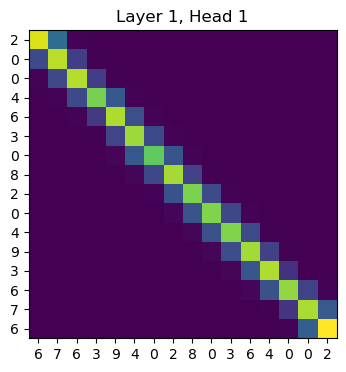

In [23]:
plot_attention_maps(x_batch, attn_maps)